In [23]:
import pickle
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [ ]:
# Distances among descriptors
path_to_pocketvec = '../processed/pocketvec_RUN/'

In [18]:
# Load background PocketVec descriptors
path_to_pocketvec_background = "../data/PocketVec_descriptors/PocketVec_descriptors.zip"
pocketvec_fps_background = {}
with zipfile.ZipFile(path_to_pocketvec_background, 'r') as z:
    for st in ['PDB-LIG', 'PDB-PD', 'AF2-LIG', 'AF2-PD']:
        pocketvec_fps_background[st] = {}
        with z.open(st + "_cut80.pkl") as f:
            pocketvec_fps_background[st] = pickle.load(f)

In [19]:
# Load tRNAs PocketVec descriptors

In [21]:
# Run tSNE

# Organize data
labels = [st + "--" + pocket for st in sorted(pocketvec_fps_background) for pocket in sorted(pocketvec_fps_background[st])]
X = [pocketvec_fps_background[i.split("--")[0]][i.split("--")[1]] for i in labels]

# Add tRNAs PocketVec descriptors

X, labels = np.array(X)[:20000], np.array(labels)

# Run tSNE
tsne = TSNE(n_components=2, perplexity=30, n_jobs=8, random_state=42)
X_embedded = tsne.fit_transform(X)

In [25]:
def calculate_density(x, y, bandwidth):
    xy = np.vstack([x, y]).T
    kde = gaussian_kde(xy.T, bw_method=bandwidth)
    density = kde(xy.T)  
    return density

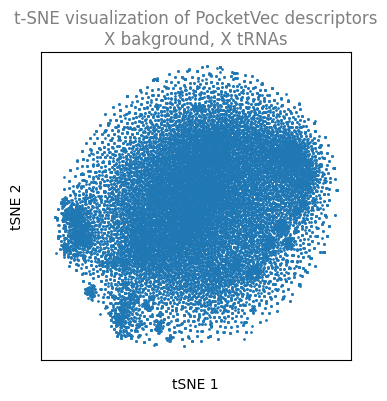

In [33]:
plt.figure(figsize=(4, 4))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=1)
plt.title("t-SNE visualization of PocketVec descriptors\nX bakground, X tRNAs", c='gray')
plt.xlabel("tSNE 1", labelpad=12)
plt.ylabel("tSNE 2", labelpad=12)
plt.xticks([])
plt.yticks([])
plt.show()
